<a href="https://colab.research.google.com/github/ChiaraTagiullo/olympic-power-structure/blob/main/Additional_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olympic Power Structure — Additional Olympic Dynamics

This notebook extends the project with three additional analyses:

1. **Summer vs Winter Olympics**  
   Do countries perform similarly across the two Olympic seasons, or do they specialize?

2. **Evolution over time of nations**  
   How has Olympic performance changed across editions?

3. **Home advantage**  
   Do host countries perform better when they organize the Games?

The analysis uses the uploaded Excel file `ds proj.xlsx`, sheet `athlete_events`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

In [4]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

raw = pd.read_excel(file_name, sheet_name="athlete_events")

print("Shape:", raw.shape)
print("\nColumns:")
print(raw.columns.tolist())

raw.head()

Saving ds proj.xlsx to ds proj.xlsx
Shape: (271116, 15)

Columns:
['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## 1. Data preparation

This dataset is at the **athlete-event** level.  
This means that in team sports the same medal appears once for each athlete, which would artificially inflate medal counts.

To avoid this problem, we count medals at the **country-event-medal** level:
- one row per `Year`, `Season`, `NOC`, `Event`, `Medal`

We also exclude the year **1906**, since the Intercalated Games are not part of the official Olympic chronology.

In [5]:
data = raw[raw["Year"] != 1906].copy()

medals = data[data["Medal"].notna()].copy()

medals_unique = medals.drop_duplicates(
    subset=["Year", "Season", "NOC", "Event", "Medal"]
).copy()

print("Original rows with medals:", medals.shape[0])
print("Unique medal units:", medals_unique.shape[0])

medals_unique.head()

Original rows with medals: 39325
Unique medal units: 18681


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


In [6]:
country_labels = (
    data.groupby("NOC")["Team"]
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.dropna().iloc[0])
    .to_dict()
)

# quick check
list(country_labels.items())[:10]

[('AFG', 'Afghanistan'),
 ('AHO', 'Netherlands Antilles'),
 ('ALB', 'Albania'),
 ('ALG', 'Algeria'),
 ('AND', 'Andorra'),
 ('ANG', 'Angola'),
 ('ANT', 'Antigua and Barbuda'),
 ('ANZ', 'Australasia'),
 ('ARG', 'Argentina'),
 ('ARM', 'Armenia')]

## 2. Summer vs Winter Olympics

We compare the total number of medals won by each country in Summer and Winter Olympics.

A country close to the diagonal performs relatively similarly in both seasons.  
Countries far below the diagonal are **summer-specialized**, while countries above it are **winter-specialized**.

In [7]:
country_season_medals = (
    medals_unique.groupby(["NOC", "Season"])
    .size()
    .reset_index(name="Medal_Count")
)

summer_winter = (
    country_season_medals
    .pivot(index="NOC", columns="Season", values="Medal_Count")
    .fillna(0)
    .reset_index()
)

summer_winter.columns.name = None

if "Summer" not in summer_winter.columns:
    summer_winter["Summer"] = 0
if "Winter" not in summer_winter.columns:
    summer_winter["Winter"] = 0

summer_winter["Total"] = summer_winter["Summer"] + summer_winter["Winter"]
summer_winter["Country"] = summer_winter["NOC"].map(country_labels)

summer_winter.head()

,NOC,Summer,Winter,Total,Country
0,AFG,2.0,0.0,2.0,Afghanistan
1,AHO,1.0,0.0,1.0,Netherlands Antilles
2,ALG,17.0,0.0,17.0,Algeria
3,ANZ,12.0,0.0,12.0,Australasia
4,ARG,74.0,0.0,74.0,Argentina


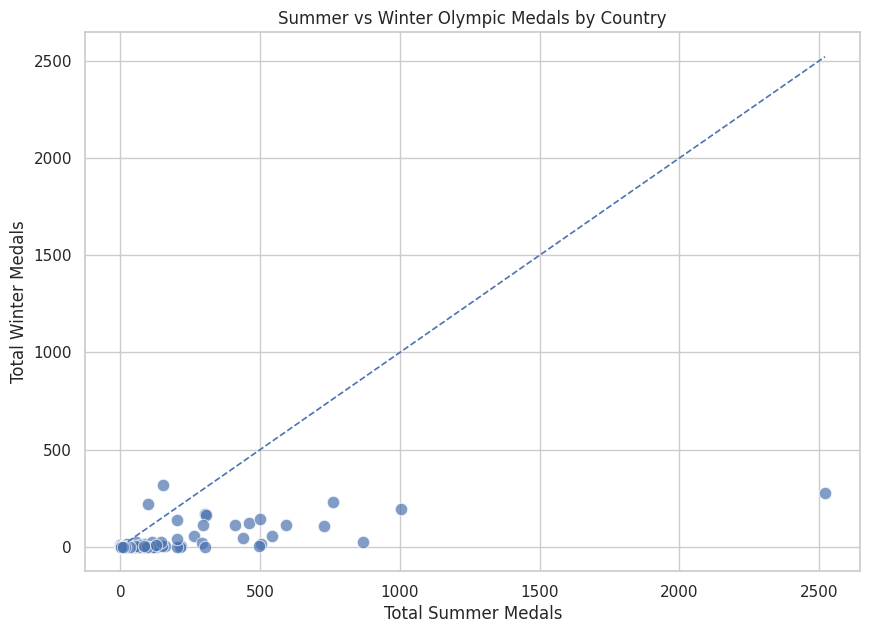

In [8]:
max_val = max(summer_winter["Summer"].max(), summer_winter["Winter"].max())

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=summer_winter,
    x="Summer",
    y="Winter",
    s=80,
    alpha=0.7
)

plt.plot([0, max_val], [0, max_val], linestyle="--", linewidth=1.2)
plt.title("Summer vs Winter Olympic Medals by Country")
plt.xlabel("Total Summer Medals")
plt.ylabel("Total Winter Medals")
plt.show()

### Interpretation

The scatter plot highlights a strong asymmetry between Summer and Winter Olympic performance.

Most countries are concentrated near the horizontal axis, indicating that they have won many medals in Summer Olympics but very few in Winter Olympics. This suggests that success in Winter sports is limited to a relatively small group of nations.

Only a few countries achieve significant results in both seasons, while several countries are clearly specialized:
- Countries located far to the right but close to the x-axis are strongly **summer-dominant**.
- Countries positioned higher relative to their Summer performance exhibit **winter specialization**.

The diagonal line represents equal performance in both seasons. The fact that almost no country lies close to this line indicates that balanced performance is rare.

Overall, this visualization suggests that Olympic success is highly dependent on structural factors such as climate, geography, and long-term investment in specific types of sports.

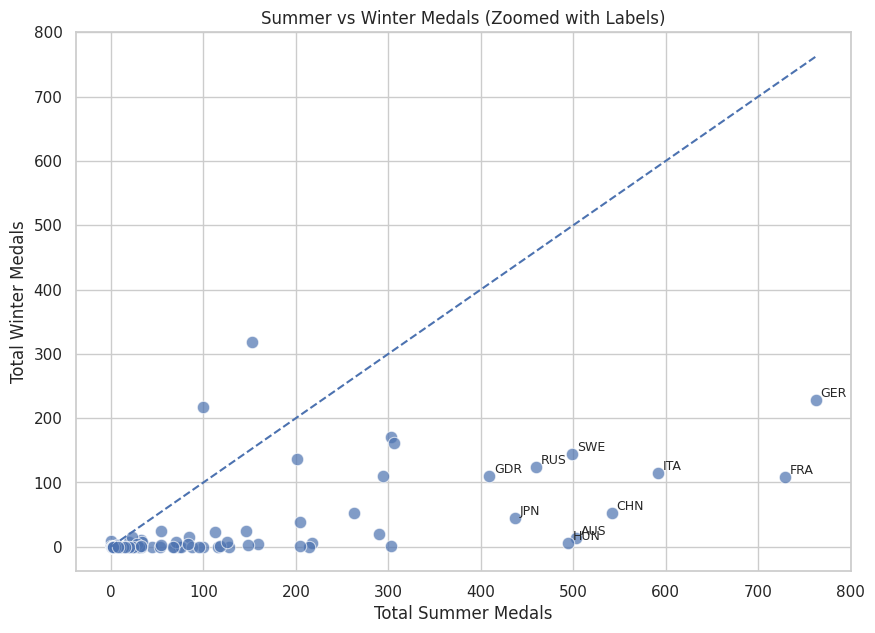

In [9]:
zoom_df = summer_winter[
    (summer_winter["Summer"] < 800) &
    (summer_winter["Winter"] < 400)
]

top_zoom = zoom_df.sort_values("Total", ascending=False).head(10)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=zoom_df,
    x="Summer",
    y="Winter",
    s=80,
    alpha=0.7
)

# linea diagonale
max_val_zoom = max(zoom_df["Summer"].max(), zoom_df["Winter"].max())
plt.plot([0, max_val_zoom], [0, max_val_zoom], linestyle="--")

# etichette
for _, row in top_zoom.iterrows():
    plt.text(
        row["Summer"] + 5,
        row["Winter"] + 5,
        row["NOC"],
        fontsize=9
    )

plt.title("Summer vs Winter Medals (Zoomed with Labels)")
plt.xlabel("Total Summer Medals")
plt.ylabel("Total Winter Medals")
plt.show()

### Zoomed interpretation

To improve readability, we created a zoomed version of the scatter plot by restricting the analysis to countries with fewer than 800 Summer medals and fewer than 400 Winter medals.

This choice does not change the underlying pattern, but it reduces the visual dominance of extreme outliers and makes the distribution of the majority of countries much easier to interpret.

In the full plot, a few highly successful countries compress most observations near the origin. In the zoomed view, intermediate-performing nations become clearly visible, allowing a more meaningful comparison of Olympic profiles.

Several patterns emerge more clearly:
- **Germany** and **France** remain among the strongest countries in this range, with Germany showing a relatively stronger Winter profile.
- **Sweden** appears closer to a balanced position, combining substantial success in both Summer and Winter Olympics.
- **Italy**, **Russia**, and **China** are clearly more successful in Summer Olympics, although they also retain some Winter presence.
- **Japan** and **Australia** appear much more summer-oriented.

More generally, the zoomed plot confirms that balanced performance across both Olympic seasons is uncommon. Even among strong and intermediate countries, most nations remain noticeably specialized.

This reinforces the idea that Olympic success is shaped by structural factors such as geography, climate, sports tradition, and long-term specialization.

## 3. Evolution of Olympic performance over time

We now study how countries' medal counts evolved across Olympic editions.

To avoid mixing Summer and Winter patterns, we begin with **Summer Olympics only**, which provide a clearer long-term comparison.

In [12]:
summer_medals = medals_unique[medals_unique["Season"] == "Summer"].copy()

country_year_summer = (
    summer_medals.groupby(["Year", "NOC"])
    .size()
    .reset_index(name="Medal_Count")
)

country_year_summer["Country"] = country_year_summer["NOC"].map(country_labels)

country_year_summer.head()

,Year,NOC,Medal_Count,Country
0,1896,AUS,3,Australia
1,1896,AUT,5,Austria
2,1896,DEN,6,Denmark
3,1896,FRA,11,France
4,1896,GBR,9,Great Britain


In [13]:
top_summer_countries = (
    country_year_summer.groupby("NOC")["Medal_Count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_summer_countries

,Medal_Count
NOC,
USA,2521
URS,1005
GBR,867
GER,762
FRA,729
ITA,592
CHN,542
AUS,503
SWE,499


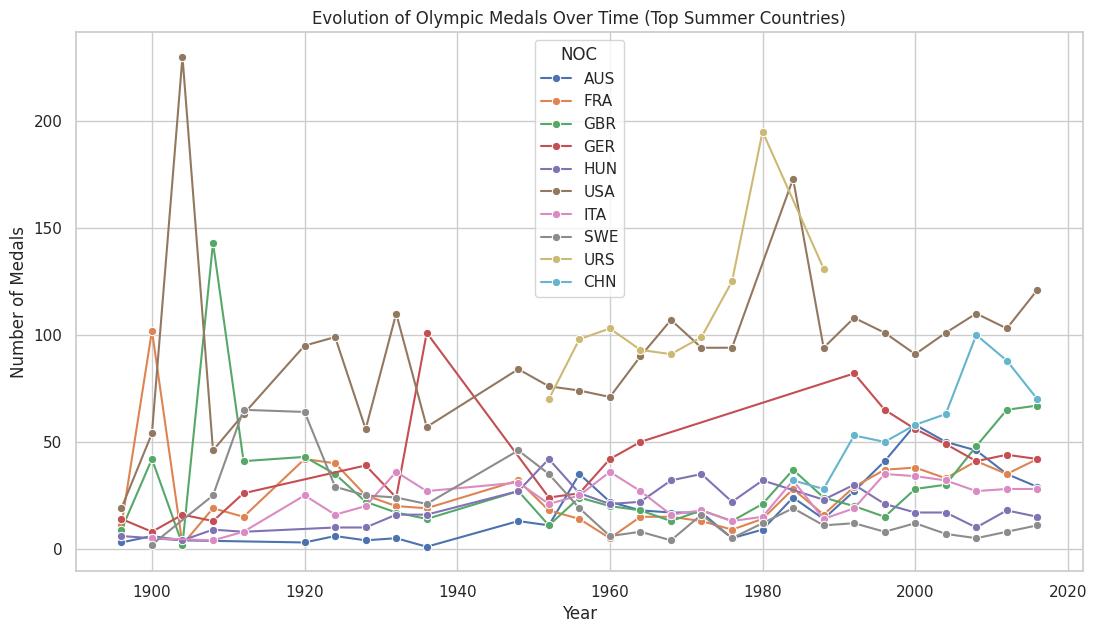

In [14]:
top_summer_list = top_summer_countries.index.tolist()

top_summer_trends = country_year_summer[
    country_year_summer["NOC"].isin(top_summer_list)
].copy()

plt.figure(figsize=(13, 7))
sns.lineplot(
    data=top_summer_trends,
    x="Year",
    y="Medal_Count",
    hue="NOC",
    marker="o"
)

plt.title("Evolution of Olympic Medals Over Time (Top Summer Countries)")
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.show()

### Interpretation

The time series highlights the evolution of Olympic performance for the top countries over more than a century.

Several distinct patterns emerge:

- The **United States (USA)** consistently dominates the rankings, maintaining a high and relatively stable number of medals across most Olympic editions. This reflects a long-term structural advantage in terms of resources, infrastructure, and sports culture.

- The **Soviet Union (URS)** shows a sharp rise starting from the 1950s, followed by a peak during the Cold War period, and a disappearance after its dissolution. This clearly illustrates the impact of geopolitical factors on Olympic performance.

- Countries such as **Germany (GER)** and **China (CHN)** display strong upward trends in more recent decades, suggesting increasing investment and strategic focus on elite sports.

- Some nations, such as **Hungary (HUN)** or **Sweden (SWE)**, show a decline in relative performance over time, indicating a shift in the global competitive landscape.

- Other countries, including **France (FRA)**, **Great Britain (GBR)**, and **Italy (ITA)**, exhibit more fluctuating patterns, alternating between periods of stronger and weaker performance.

Overall, the graph demonstrates that Olympic success is not static but evolves over time, reflecting broader economic, political, and institutional changes. It also highlights how global competition has intensified, with more countries emerging as strong contenders in recent decades.

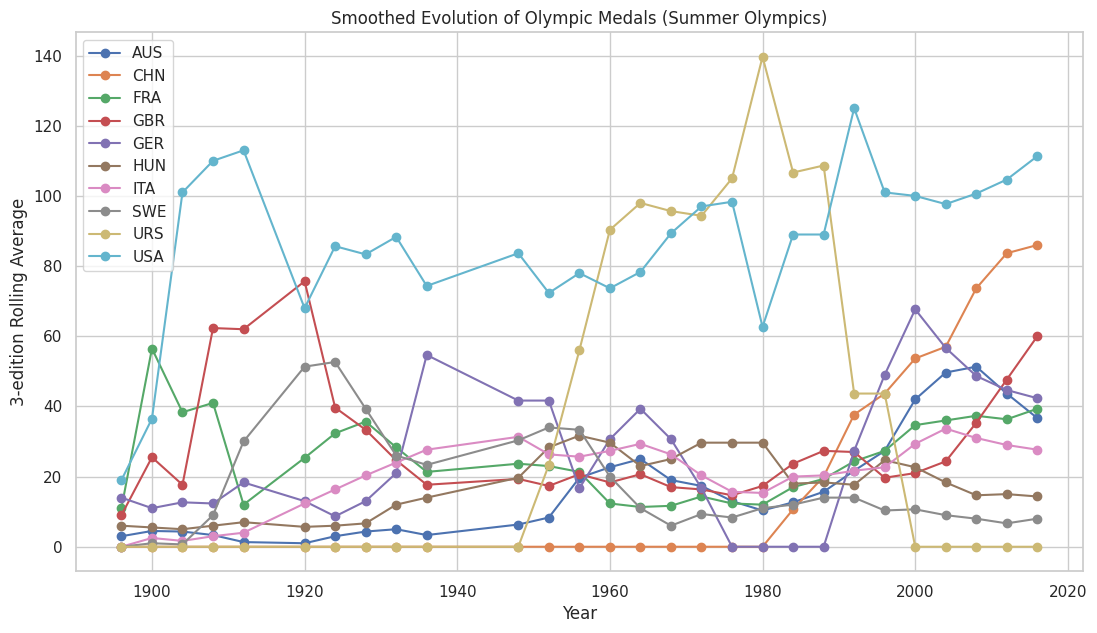

In [15]:
summer_pivot = (
    top_summer_trends
    .pivot_table(index="Year", columns="NOC", values="Medal_Count", fill_value=0)
    .sort_index()
)

summer_smooth = summer_pivot.rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(13, 7))
for col in summer_smooth.columns:
    plt.plot(summer_smooth.index, summer_smooth[col], marker="o", label=col)

plt.title("Smoothed Evolution of Olympic Medals (Summer Olympics)")
plt.xlabel("Year")
plt.ylabel("3-edition Rolling Average")
plt.legend()
plt.show()

### Interpretation

The smoothed time series provides a clearer view of long-term trends by reducing short-term fluctuations across Olympic editions.


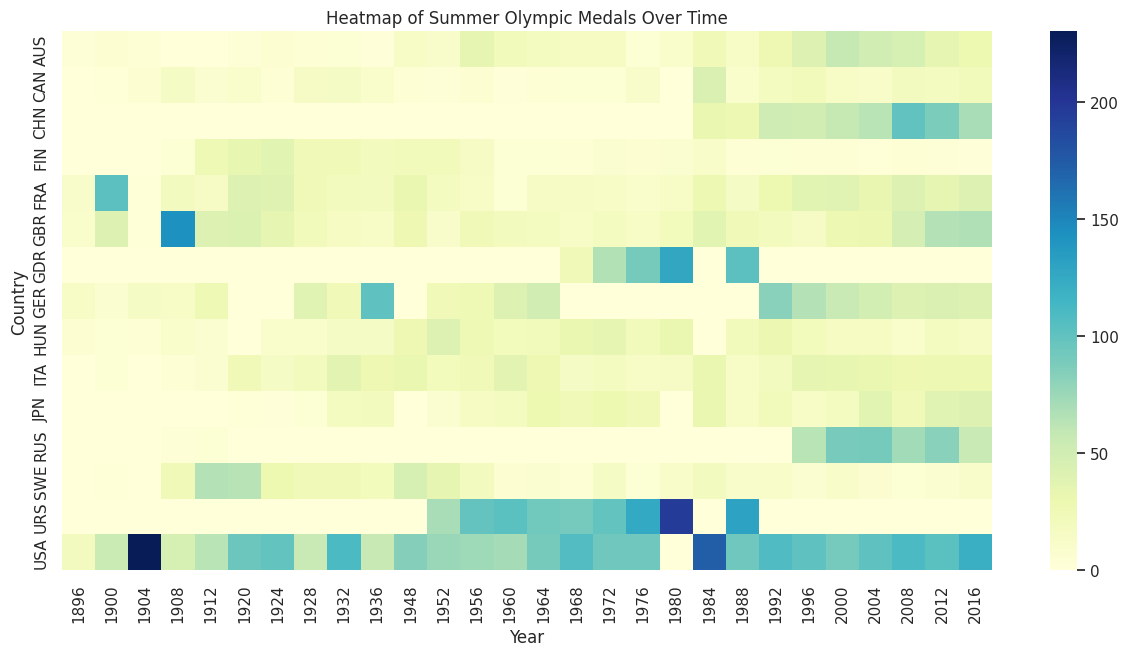

In [16]:
top15_summer = (
    country_year_summer.groupby("NOC")["Medal_Count"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

heatmap_summer = (
    country_year_summer[country_year_summer["NOC"].isin(top15_summer)]
    .pivot_table(index="NOC", columns="Year", values="Medal_Count", fill_value=0)
)

plt.figure(figsize=(15, 7))
sns.heatmap(heatmap_summer, cmap="YlGnBu")
plt.title("Heatmap of Summer Olympic Medals Over Time")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()

### Interpretation

The heatmap provides a compact overview of medal intensity across countries and Olympic editions, making it easier to identify temporal patterns that are less visible in line plots.

Compared to previous visualizations, several additional insights emerge:

- It becomes easier to identify **periods of peak performance** for each country. For example, the Soviet Union shows a clearly concentrated period of high intensity between the 1960s and 1980s.

- The visualization highlights **temporal clustering**, where strong performances are sustained over consecutive editions rather than occurring as isolated spikes.

- Some countries display **consistent medium-level performance** over long periods (e.g., France, Great Britain), which is less apparent in line charts dominated by top performers.

- The heatmap also makes it easier to detect **structural breaks**, such as the disappearance of the Soviet Union and the later emergence of new strong competitors.

- Finally, the increasing density of darker colors in recent decades suggests a **broader distribution of success**, indicating that more countries are becoming competitive at higher levels.

Overall, the heatmap complements previous analyses by emphasizing the temporal structure and persistence of Olympic performance.

Finally, we compare early and late performance to identify countries with the strongest growth or decline.

In [17]:
summer_years = sorted(country_year_summer["Year"].unique())

early_years = summer_years[:5]
late_years = summer_years[-5:]

early_perf = (
    country_year_summer[country_year_summer["Year"].isin(early_years)]
    .groupby("NOC")["Medal_Count"]
    .mean()
    .reset_index(name="Early_Avg")
)

late_perf = (
    country_year_summer[country_year_summer["Year"].isin(late_years)]
    .groupby("NOC")["Medal_Count"]
    .mean()
    .reset_index(name="Late_Avg")
)

comparison_summer = early_perf.merge(late_perf, on="NOC", how="outer").fillna(0)
comparison_summer["Change"] = comparison_summer["Late_Avg"] - comparison_summer["Early_Avg"]
comparison_summer["Country"] = comparison_summer["NOC"].map(country_labels)

comparison_summer.sort_values("Change", ascending=False).head(15)

,NOC,Early_Avg,Late_Avg,Change,Country
20,CHN,0.000000,75.8,75.800000,China
95,RUS,4.000000,77.8,73.800000,Russia
5,AUS,4.333333,43.6,39.266667,Australia
60,JPN,0.000000,31.8,31.800000,Japan
43,GER,15.400000,46.4,31.000000,Germany
64,KOR,0.000000,27.6,27.600000,South Korea
57,ITA,5.666667,29.8,24.133333,Italy
117,USA,82.400000,105.2,22.800000,United States
115,UKR,0.000000,20.6,20.600000,Ukraine
26,CUB,3.000000,21.0,18.000000,Cuba


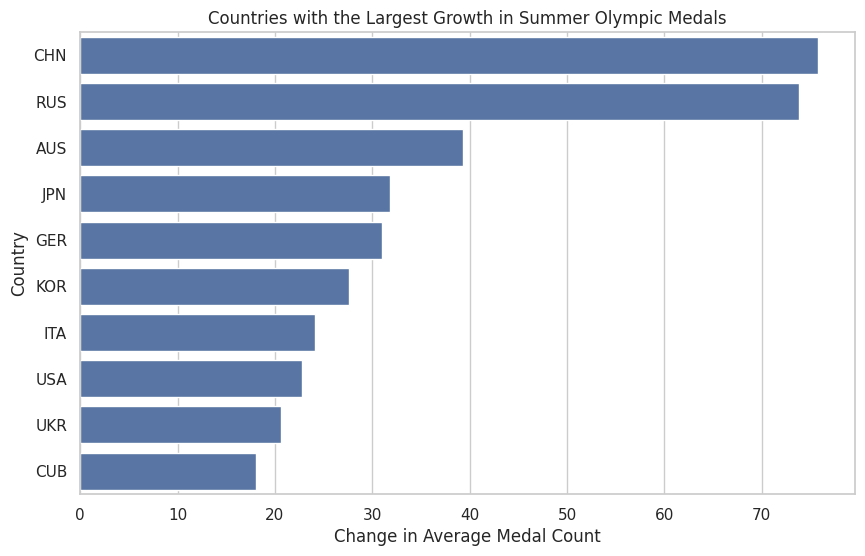

In [18]:
top_growth = comparison_summer.sort_values("Change", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_growth, x="Change", y="NOC")
plt.title("Countries with the Largest Growth in Summer Olympic Medals")
plt.xlabel("Change in Average Medal Count")
plt.ylabel("Country")
plt.show()

### Interpretation

This chart highlights the countries that experienced the largest increase in Olympic performance between the early and recent periods.

The most striking result is the strong growth of **China (CHN)** and **Russia (RUS)**, which significantly outpace other countries. This reflects major structural changes, including increased investment in elite sports and broader geopolitical transformations.

Several other countries, such as **Australia (AUS)**, **Japan (JPN)**, and **South Korea (KOR)**, also show substantial improvement, suggesting the emergence of new competitive nations, particularly in the Asia-Pacific region.

Interestingly, even historically dominant countries like the **United States (USA)** appear in the ranking, although with a more moderate increase. This indicates that while they remain strong, their growth is less pronounced compared to emerging competitors.

Overall, this analysis reveals a shift in the global balance of Olympic performance, with new countries closing the gap and contributing to a more competitive and diversified landscape.

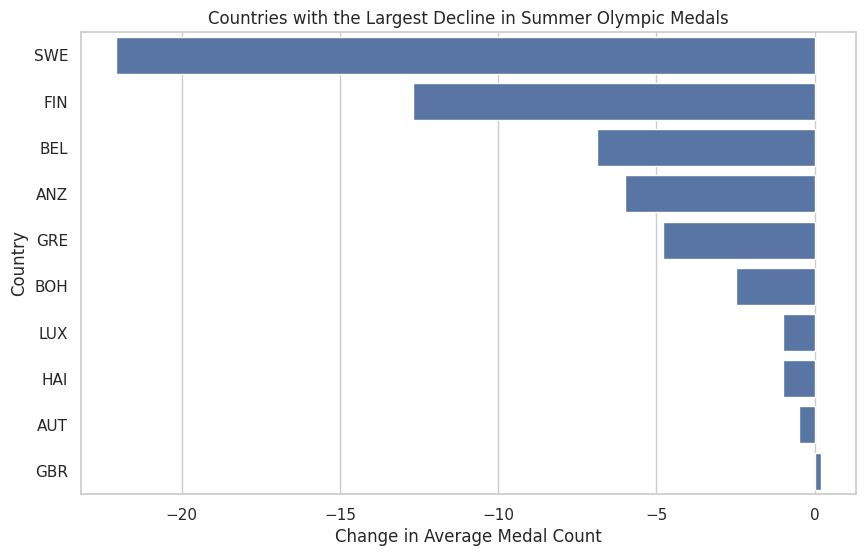

In [19]:
top_decline = comparison_summer.sort_values("Change", ascending=True).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_decline, x="Change", y="NOC")
plt.title("Countries with the Largest Decline in Summer Olympic Medals")
plt.xlabel("Change in Average Medal Count")
plt.ylabel("Country")
plt.show()

### Interpretation

This chart focuses on countries that experienced the largest decline in Olympic performance over time.

Unlike the growth analysis, which highlights emerging powers, this visualization reveals a gradual loss of competitiveness for several historically successful nations.

Countries such as **Sweden (SWE)** and **Finland (FIN)** show the most significant declines, suggesting a long-term reduction in their relative Olympic performance. This may reflect structural changes, including reduced dominance in traditional sports or increased global competition.

Other countries, such as **Belgium (BEL)** and **Greece (GRE)**, also exhibit noticeable declines, indicating that maintaining a strong Olympic presence over time is challenging.

In some cases, the observed decrease may also be linked to historical or geopolitical changes (e.g., **BOH**, **ANZ**), highlighting how shifts in national structures can impact long-term performance.

Overall, this analysis complements the previous one by showing that Olympic success is not only about growth, but also about the ability to sustain competitiveness in an increasingly global and competitive environment.

## 4. Home advantage

To test whether hosting the Games boosts performance, we compare host countries' medal counts in the hosting edition with their performance in nearby editions of the **same season**.

This is more meaningful than simply comparing hosts vs non-hosts, because host countries are often already strong countries.

In [20]:
hosts = pd.DataFrame({
    "Year": [
        1896, 1900, 1904, 1908, 1912, 1920, 1924, 1928, 1932, 1936,
        1948, 1952, 1956, 1960, 1964, 1968, 1972, 1976, 1980, 1984,
        1988, 1992, 1996, 2000, 2004, 2008, 2012, 2016,
        1924, 1928, 1932, 1936, 1948, 1952, 1956, 1960, 1964, 1968,
        1972, 1976, 1980, 1984, 1988, 1992, 1994, 1998, 2002, 2006,
        2010, 2014
    ],
    "Season": [
        "Summer","Summer","Summer","Summer","Summer","Summer","Summer","Summer","Summer","Summer",
        "Summer","Summer","Summer","Summer","Summer","Summer","Summer","Summer","Summer","Summer",
        "Summer","Summer","Summer","Summer","Summer","Summer","Summer","Summer",
        "Winter","Winter","Winter","Winter","Winter","Winter","Winter","Winter","Winter","Winter",
        "Winter","Winter","Winter","Winter","Winter","Winter","Winter","Winter","Winter","Winter",
        "Winter","Winter"
    ],
    "Host_NOC": [
        "GRE","FRA","USA","GBR","SWE","BEL","FRA","NED","USA","GER",
        "GBR","FIN","AUS","ITA","JPN","MEX","FRG","CAN","URS","USA",
        "KOR","ESP","USA","AUS","GRE","CHN","GBR","BRA",
        "FRA","SUI","USA","GER","SUI","NOR","ITA","USA","AUT","FRA",
        "JPN","AUT","USA","YUG","CAN","FRA","NOR","JPN","USA","ITA",
        "CAN","RUS"
    ]
})

hosts.head()

,Year,Season,Host_NOC
0,1896,Summer,GRE
1,1900,Summer,FRA
2,1904,Summer,USA
3,1908,Summer,GBR
4,1912,Summer,SWE


We compute medals by country, year, and season, then isolate the host country in each edition.

In [21]:
country_year_season = (
    medals_unique.groupby(["Year", "Season", "NOC"])
    .size()
    .reset_index(name="Medal_Count")
)

host_perf = country_year_season.merge(hosts, on=["Year", "Season"], how="left")
host_perf["Is_Host"] = host_perf["NOC"] == host_perf["Host_NOC"]

host_perf.head()

,Year,Season,NOC,Medal_Count,Host_NOC,Is_Host
0,1896,Summer,AUS,3,GRE,False
1,1896,Summer,AUT,5,GRE,False
2,1896,Summer,DEN,6,GRE,False
3,1896,Summer,FRA,11,GRE,False
4,1896,Summer,GBR,9,GRE,False


In [22]:
host_only = host_perf[host_perf["Is_Host"]].copy()
host_only["Country"] = host_only["NOC"].map(country_labels)

host_only.sort_values(["Season", "Year"]).head(20)

,Year,Season,NOC,Medal_Count,Host_NOC,Is_Host,Country
6,1896,Summer,GRE,44,GRE,True,Greece
19,1900,Summer,FRA,102,FRA,True,France
45,1904,Summer,USA,230,USA,True,United States
54,1908,Summer,GBR,143,GBR,True,Great Britain
82,1912,Summer,SWE,65,SWE,True,Sweden
85,1920,Summer,BEL,42,BEL,True,Belgium
114,1924,Summer,FRA,40,FRA,True,France
171,1928,Summer,NED,23,NED,True,Netherlands
223,1932,Summer,USA,110,USA,True,United States
245,1936,Summer,GER,101,GER,True,Germany


To measure the hosting effect, we compare each host country's medal count with nearby editions of the same season.

`Relative_Edition = 0` is the hosting year.  
`-1` is the previous edition of the same season, `+1` the next one, and so on.

In [23]:
season_years = {
    season: sorted(country_year_season[country_year_season["Season"] == season]["Year"].unique())
    for season in ["Summer", "Winter"]
}

rows = []

for _, host in host_only.iterrows():
    host_year = host["Year"]
    host_season = host["Season"]
    host_noc = host["NOC"]

    years_list = season_years[host_season]
    host_idx = years_list.index(host_year)

    country_series = country_year_season[
        (country_year_season["NOC"] == host_noc) &
        (country_year_season["Season"] == host_season)
    ].copy()

    country_series["Relative_Edition"] = country_series["Year"].apply(
        lambda y: years_list.index(y) - host_idx
    )

    country_series["Host_Year"] = host_year
    country_series["Host_Season"] = host_season
    country_series["Host_NOC"] = host_noc

    rows.append(country_series)

host_window = pd.concat(rows, ignore_index=True)
host_window = host_window[host_window["Relative_Edition"].between(-2, 2)].copy()

host_window.head()

,Year,Season,NOC,Medal_Count,Relative_Edition,Host_Year,Host_Season,Host_NOC
0,1896,Summer,GRE,44,0,1896,Summer,GRE
1,1904,Summer,GRE,2,2,1896,Summer,GRE
20,1896,Summer,FRA,11,-1,1900,Summer,FRA
21,1900,Summer,FRA,102,0,1900,Summer,FRA
22,1904,Summer,FRA,2,1,1900,Summer,FRA


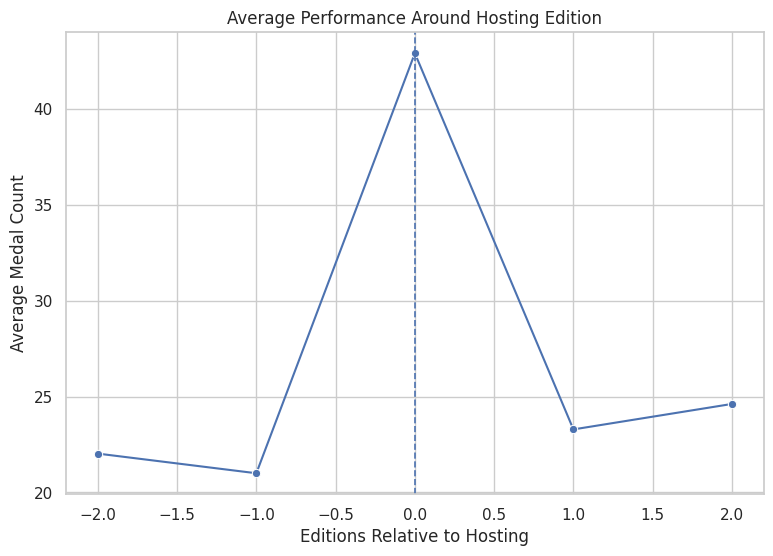

In [24]:
avg_host_window = (
    host_window.groupby("Relative_Edition")["Medal_Count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 6))
sns.lineplot(
    data=avg_host_window,
    x="Relative_Edition",
    y="Medal_Count",
    marker="o"
)

plt.axvline(0, linestyle="--", linewidth=1.2)
plt.title("Average Performance Around Hosting Edition")
plt.xlabel("Editions Relative to Hosting")
plt.ylabel("Average Medal Count")
plt.show()

### Interpretation

This plot shows the average Olympic performance of host countries relative to the hosting edition, providing a clear view of the "home advantage" effect.

A strong and immediate pattern emerges: medal counts peak sharply at the hosting edition (relative position 0), reaching a level significantly higher than in the surrounding editions.

Before hosting, performance remains relatively stable, with no clear upward trend, suggesting that the boost is not simply part of a gradual improvement.

After the hosting year, medal counts drop again, although they tend to remain slightly above pre-hosting levels. This may indicate short-term legacy effects, such as improved infrastructure or continued investment in sports.

Overall, the graph provides strong evidence of a **home advantage effect**, where hosting the Olympic Games is associated with a significant and temporary increase in performance.

In [25]:
boost_rows = []

for (season, noc, host_year), grp in host_window.groupby(["Host_Season", "Host_NOC", "Host_Year"]):
    host_value = grp.loc[grp["Relative_Edition"] == 0, "Medal_Count"]
    baseline = grp.loc[grp["Relative_Edition"] != 0, "Medal_Count"]

    if len(host_value) == 1 and len(baseline) > 0:
        host_medals = host_value.iloc[0]
        baseline_avg = baseline.mean()
        boost_abs = host_medals - baseline_avg
        boost_pct = (boost_abs / baseline_avg * 100) if baseline_avg > 0 else np.nan

        boost_rows.append({
            "Season": season,
            "NOC": noc,
            "Country": country_labels.get(noc, noc),
            "Host_Year": host_year,
            "Host_Medals": host_medals,
            "Baseline_Avg": baseline_avg,
            "Boost_Abs": boost_abs,
            "Boost_Pct": boost_pct
        })

host_boost = pd.DataFrame(boost_rows)
host_boost.sort_values("Boost_Abs", ascending=False).head(20)

,Season,NOC,Country,Host_Year,Host_Medals,Baseline_Avg,Boost_Abs,Boost_Pct
24,Summer,USA,United States,1904,230,45.500000,184.500000,405.494505
11,Summer,GBR,Great Britain,1908,143,32.000000,111.000000,346.875000
8,Summer,FRA,France,1900,102,10.666667,91.333333,856.250000
23,Summer,URS,Soviet Union,1980,195,118.333333,76.666667,64.788732
26,Summer,USA,United States,1984,173,98.666667,74.333333,75.337838
14,Summer,GER,Germany,1936,101,29.000000,72.000000,248.275862
15,Summer,GRE,Greece,1896,44,2.000000,42.000000,2100.000000
25,Summer,USA,United States,1932,110,74.000000,36.000000,48.648649
2,Summer,BEL,Belgium,1920,42,7.500000,34.500000,460.000000
5,Summer,CHN,China,2008,100,69.750000,30.250000,43.369176


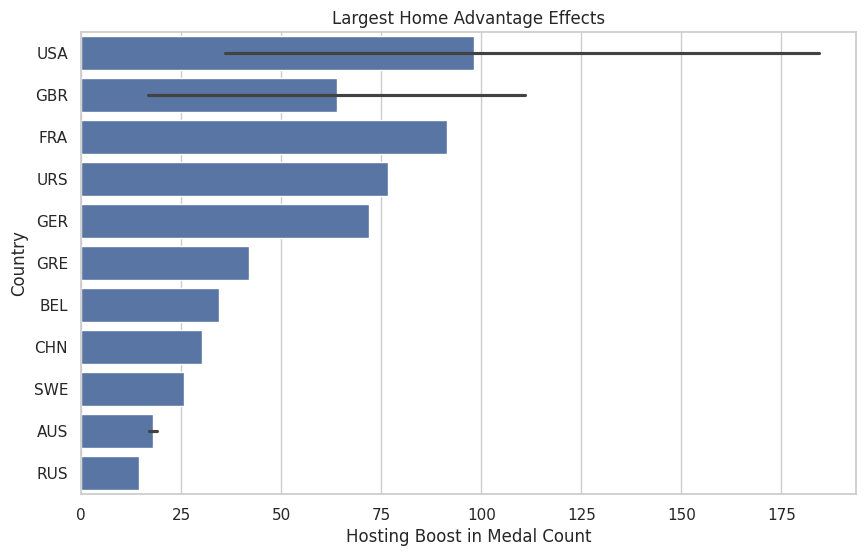

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=host_boost.sort_values("Boost_Abs", ascending=False).head(15),
    x="Boost_Abs",
    y="NOC"
)

plt.title("Largest Home Advantage Effects")
plt.xlabel("Hosting Boost in Medal Count")
plt.ylabel("Country")
plt.show()

### Interpretation

This chart identifies the countries that experienced the largest increase in medal counts when hosting the Olympic Games.

The results show that the **home advantage effect varies significantly across countries**. Some nations benefit much more than others from hosting the Games.

The **United States (USA)** exhibits the largest absolute increase, reflecting both its already high performance level and its ability to further amplify results when hosting.

Other major countries, such as **France (FRA)**, **Great Britain (GBR)**, and the **Soviet Union (URS)**, also display substantial gains, suggesting that well-established sporting systems are particularly able to capitalize on the hosting opportunity.

At the same time, smaller boosts observed for countries like **Australia (AUS)** or **Russia (RUS)** indicate that the home advantage is not uniform and may depend on factors such as existing performance level, investment strategies, and historical context.

Overall, this analysis highlights that while hosting generally leads to improved performance, the magnitude of the effect is highly heterogeneous and influenced by country-specific characteristics.

## Conclusion

These additional analyses complement the previous notebooks by introducing three new dimensions:

- **Seasonal specialization**: countries do not perform equally in Summer and Winter Olympics.
- **Temporal dynamics**: Olympic success evolves over time and is not a fixed hierarchy.
- **Contextual effects**: hosting the Games may create a measurable performance boost.

Together, these results strengthen the idea that Olympic performance depends not only on economic resources, but also on structural specialization and historical context.